<a href="https://colab.research.google.com/github/jessxleee/SIT-UofG-QC-Assignment/blob/main/BB84-Attacker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

In [59]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math
import random

1. Setup & Quantum Random Bit Generator

In [60]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()

# ── Protocol settings ──────────────────────────────────────────────────────
TEST_FRACTION    = 0.5   # proportion of sifted key used for error checking
ATTACK_THRESHOLD = 0.1   # abort if error rate exceeds this

def quantum_random_bit():
    """Generate a truly random bit by measuring |+⟩"""
    qc = QuantumCircuit(1, 1) # 1 qubit, 1 classical bit
    qc.h(0)                   # Hadamard: |0⟩ → 1/√2 (|0⟩ + |1⟩)
    qc.measure(0, 0)          # Collapse the superposition
    result = simulator.run(qc, shots=1).result()
    return int(list(result.get_counts().keys())[0])

def quantum_random_bits(n):
    return [quantum_random_bit() for _ in range(n)]

2. Alice randomly chooses its data bits and bases and encodes her qubits


In [61]:
N = 100  # number of qubits to send

alice_bits  = quantum_random_bits(N)   # the secret bits
alice_bases = quantum_random_bits(N)   # 0 = rectilinear (+), 1 = diagonal (×)

print("Alice bits: ", alice_bits)
print("Alice bases:", alice_bases)

def encode_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)          # flip to |1⟩
    if basis == 1:
        qc.h(0)          # rotate to diagonal basis
    return qc

Alice bits:  [0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1]
Alice bases: [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1]


3. Eve intercepts and resends


In [62]:
eve_bases = quantum_random_bits(N)
print("Eve bases: ", eve_bases)

def eve_intercept(qc, eve_basis):
    # Eve measures
    if eve_basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    result = simulator.run(qc, shots=1).result()
    eve_bit = int(list(result.get_counts().keys())[0])

    # Eve re-encodes what she measured into a fresh qubit
    new_qc = QuantumCircuit(1, 1)
    if eve_bit == 1:
        new_qc.x(0)
    if eve_basis == 1:
        new_qc.h(0)

    return new_qc

Eve bases:  [1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1]


4. Bob measures the (intercepted) qubits

In [63]:
bob_bases = quantum_random_bits(N)

def measure_qubit(qc, basis):
    """Bob measures in his chosen basis"""
    if basis == 1:
        qc.h(0)          # rotate back from diagonal
    qc.measure(0, 0)
    result = simulator.run(qc, shots=1).result()
    return int(list(result.get_counts().keys())[0])

bob_results = []
for i in range(N):
    qc = encode_qubit(alice_bits[i], alice_bases[i])
    qc = eve_intercept(qc, eve_bases[i])
    bit = measure_qubit(qc, bob_bases[i])
    bob_results.append(bit)

print("Bob bases:  ", bob_bases)
print("Bob results:", bob_results)

Bob bases:   [1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0]
Bob results: [0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1]



5. Sifting (Classical Channel)


In [64]:
# === SIFTING ===
sifted_alice = []
sifted_bob   = []

for i in range(N):
    if alice_bases[i] == bob_bases[i]:   # bases matched
        sifted_alice.append(alice_bits[i])
        sifted_bob.append(bob_results[i])

print(f"Sifted key length: {len(sifted_alice)} bits")
print("Alice sifted key: ", sifted_alice)
print("Bob sifted key:   ", sifted_bob)

Sifted key length: 54 bits
Alice sifted key:  [1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1]
Bob sifted key:    [1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1]


6. Error Checking — Randomly select test positions using quantum randomnes

In [65]:
def pick_test_indices(pool_size, target_count):
    selected = set()
    rounds   = 0

    while len(selected) < target_count and rounds < 10:
        flips = quantum_random_bits(pool_size)
        for idx, flip in enumerate(flips):
            if flip == 1 and idx not in selected:
                selected.add(idx)
            if len(selected) == target_count:
                break
        rounds += 1

    # Deterministic fallback — only fills any remaining gap, not used for randomness
    for idx in range(pool_size):
        if len(selected) == target_count:
            break
        selected.add(idx)

    return sorted(selected)


if len(sifted_alice) == 0:
    test_size    = 0
    test_indices = []
    errors       = 0
    error_rate   = 1.0
else:
    test_size    = max(1, math.floor(len(sifted_alice) * TEST_FRACTION))
    test_indices = pick_test_indices(len(sifted_alice), test_size)

    errors     = sum(sifted_alice[i] != sifted_bob[i] for i in test_indices)
    error_rate = errors / test_size

# Build final key from positions NOT used for testing
final_alice_key = [sifted_alice[i] for i in range(len(sifted_alice)) if i not in test_indices]
final_bob_key   = [sifted_bob[i]   for i in range(len(sifted_bob))   if i not in test_indices]

attack_detected = error_rate > ATTACK_THRESHOLD
keys_match      = final_alice_key == final_bob_key


7. BB84 Security Report

In [66]:

print("=" * 45)
print("       BB84 PROTOCOL — SECURITY REPORT")
print("=" * 45)
print(f"  Qubits sent:          {N}")
print(f"  Sifted key length:    {len(sifted_alice)} bits")
print(f"  Test bits sampled:    {test_size} bits")
print(f"  Errors found:         {errors}/{test_size}")
print(f"  Error rate:           {error_rate:.0%}")
print(f"  Detection threshold:  {ATTACK_THRESHOLD:.0%}")
print(f"  Attack detected:      {'YES' if attack_detected else 'NO'}")
print(f"  Final key length:     {len(final_alice_key)} bits")
print(f"  Keys match:           {'YES ' if keys_match else 'NO'}")
print("-" * 45)

if attack_detected:
    print("Key exchange ABORTED. Do not use key.")
else:
    print("  Attacker present but not detected this run (low-probability outcome).")
    print(f"  Alice final key: {final_alice_key}")
    print(f"  Bob   final key: {final_bob_key}")

       BB84 PROTOCOL — SECURITY REPORT
  Qubits sent:          100
  Sifted key length:    54 bits
  Test bits sampled:    27 bits
  Errors found:         3/27
  Error rate:           11%
  Detection threshold:  10%
  Attack detected:      YES
  Final key length:     27 bits
  Keys match:           NO
---------------------------------------------
Key exchange ABORTED. Do not use key.


8. Quantum Circuit Diagram — Alice → Eve → Bob



Example: Alice bit=1, diagonal basis | Eve uses rectilinear (wrong) | Bob uses diagonal


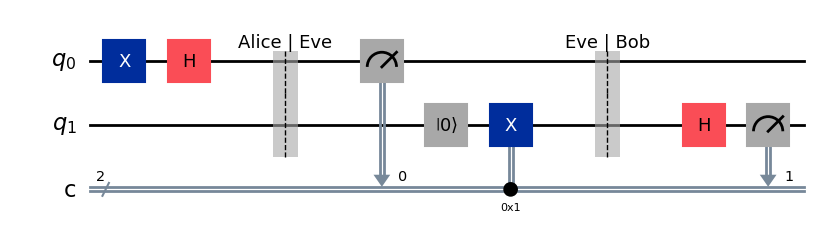

In [67]:
def bb84_eve_circuit(alice_bit, alice_basis, eve_basis, bob_basis):

    qc = QuantumCircuit(2, 2)

    # Alice encodes onto q0
    if alice_bit == 1:
        qc.x(0)
    if alice_basis == 1:
        qc.h(0)

    qc.barrier(label='Alice | Eve')

    # Eve measures q0 in her basis, then re-encodes onto q1
    if eve_basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    qc.reset(1)
    qc.x(1).c_if(qc.cregs[0], 1)
    if eve_basis == 1:
        qc.h(1)

    qc.barrier(label='Eve | Bob')

    # Bob measures q1 in his basis
    if bob_basis == 1:
        qc.h(1)
    qc.measure(1, 1)

    return qc

print("Example: Alice bit=1, diagonal basis | Eve uses rectilinear (wrong) | Bob uses diagonal")
bb84_eve_circuit(1, 1, 0, 1).draw('mpl')


9. Statistics Bar Charts

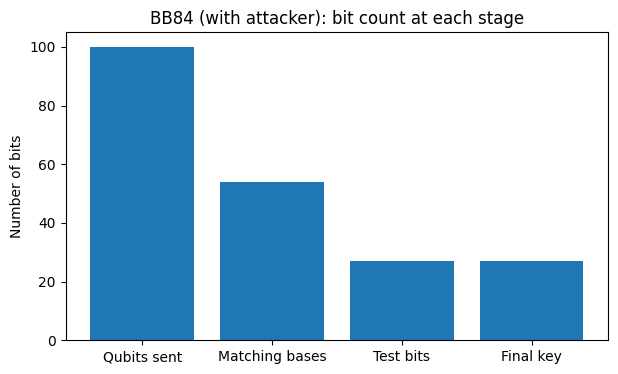

In [68]:
import matplotlib.pyplot as plt

labels = ["Qubits sent", "Matching bases", "Test bits", "Final key"]
values = [N, len(sifted_alice), test_size, len(final_alice_key)]

plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.title("BB84 (with attacker): bit count at each stage")
plt.ylabel("Number of bits")
plt.show()



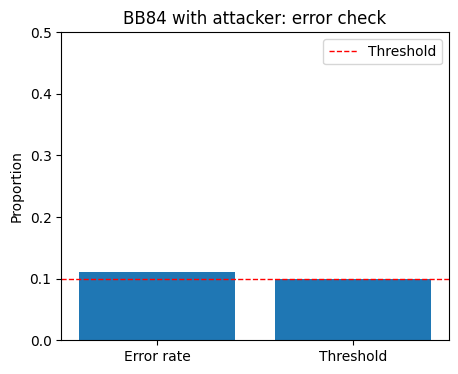

In [69]:
plt.figure(figsize=(5, 4))
plt.bar(["Error rate", "Threshold"], [error_rate, ATTACK_THRESHOLD])
plt.title("BB84 with attacker: error check")
plt.ylabel("Proportion")
plt.ylim(0, max(0.5, error_rate + 0.1, ATTACK_THRESHOLD + 0.1))
plt.axhline(ATTACK_THRESHOLD, color='red', linestyle='--', linewidth=1, label='Threshold')
plt.legend()

plt.show()


---
## Part 2 — Simulation: Detection Across Different Interception Rates

This section runs many trials across
different interception rates to show how detection probability and error rate
scale with how aggressively Eve eavesdrops.

**Eve's strategy:** intercept each qubit independently with probability `p`.
- `p = 0.0` → no attack, baseline error rate near 0%
- `p = 0.4` → boundary case, ~10% error rate, detection is unreliable
- `p = 1.0` → full attack, ~25% error rate, almost always detected

In [70]:

TRIALS          = 50    # runs per interception rate
INTERCEPT_RATES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # Eve's interception fraction


In [71]:
# For each interception rate, run TRIALS full BB84 exchanges
# and record the error rate and whether the attack was detected.

avg_errors      = []
detection_rates = []

for rate in INTERCEPT_RATES:
    trial_errors    = []
    trial_detected  = []

    for _ in range(TRIALS):
        # Generate bits and bases
        t_alice_bits  = quantum_random_bits(N)
        t_alice_bases = quantum_random_bits(N)
        t_bob_bases   = quantum_random_bits(N)
        t_eve_bases   = quantum_random_bits(N)

        # Bob measures — Eve intercepts each qubit with probability rate
        t_bob_results = []
        for i in range(N):
            qc = encode_qubit(t_alice_bits[i], t_alice_bases[i])
            if random.random() < rate:
                qc = eve_intercept(qc, t_eve_bases[i])
            t_bob_results.append(measure_qubit(qc, t_bob_bases[i]))

        # Sifting
        t_sifted_alice = [t_alice_bits[i]  for i in range(N) if t_alice_bases[i] == t_bob_bases[i]]
        t_sifted_bob   = [t_bob_results[i] for i in range(N) if t_alice_bases[i] == t_bob_bases[i]]

        # Error check on first sample_size bits
        t_errors = sum(a != b for a, b in zip(t_sifted_alice[:test_size], t_sifted_bob[:test_size]))
        t_rate   = t_errors / test_size

        trial_errors.append(t_rate)
        trial_detected.append(t_rate > ATTACK_THRESHOLD)

    avg_errors.append(sum(trial_errors) / TRIALS)
    detection_rates.append(sum(trial_detected) / TRIALS)
    print(f"  Eve intercepts {int(rate*100):>3}% — avg error: {avg_errors[-1]:.1%}  detected: {detection_rates[-1]:.0%}")

print("\nDone.")


  Eve intercepts   0% — avg error: 0.0%  detected: 0%
  Eve intercepts  20% — avg error: 5.2%  detected: 18%
  Eve intercepts  40% — avg error: 11.7%  detected: 66%
  Eve intercepts  60% — avg error: 16.5%  detected: 86%
  Eve intercepts  80% — avg error: 19.5%  detected: 96%
  Eve intercepts 100% — avg error: 25.3%  detected: 98%

Done.


/tmp/ipykernel_23120/889081413.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=pct_labels)


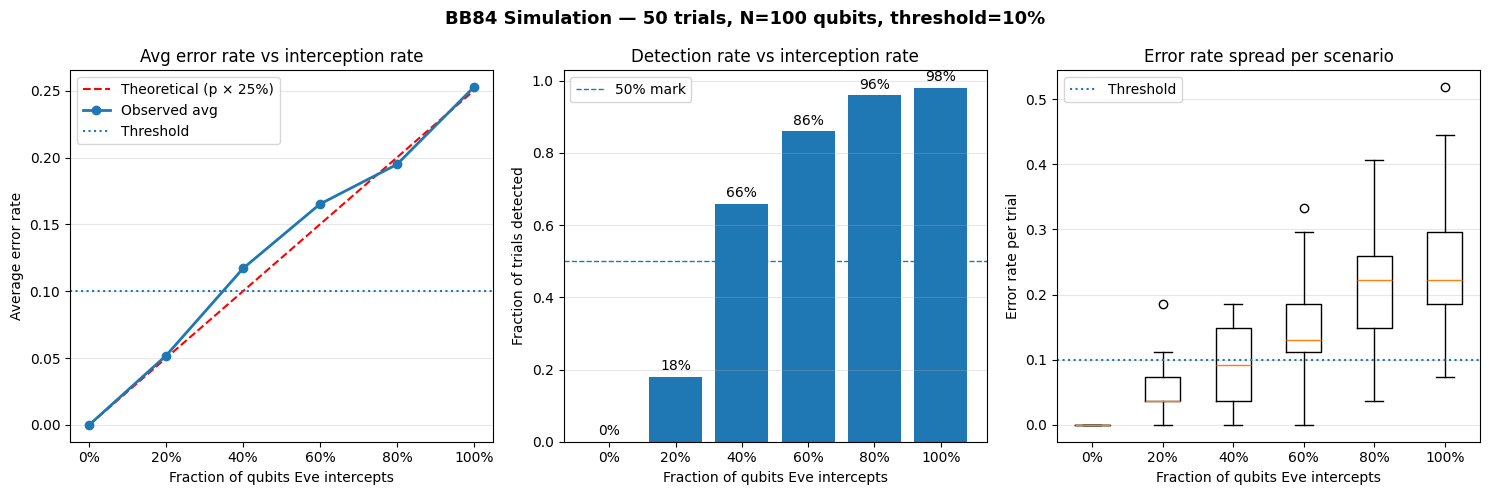

In [72]:
pct_labels      = [f"{int(r * 100)}%" for r in INTERCEPT_RATES]
theoretical_err = [r * 0.25 for r in INTERCEPT_RATES]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"BB84 Simulation — {TRIALS} trials, N={N} qubits, threshold={ATTACK_THRESHOLD:.0%}",
             fontsize=13, fontweight='bold')

# Chart 1: observed vs theoretical error rate
plt.sca(ax1)
plt.plot(pct_labels, theoretical_err, 'r--', linewidth=1.5, label='Theoretical (p × 25%)')
plt.plot(pct_labels, avg_errors, 'o-', linewidth=2, label='Observed avg')
plt.axhline(ATTACK_THRESHOLD, linestyle=':', linewidth=1.5, label='Threshold')
plt.title("Avg error rate vs interception rate")
plt.xlabel("Fraction of qubits Eve intercepts")
plt.ylabel("Average error rate")
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Chart 2: detection rate
plt.sca(ax2)
plt.bar(pct_labels, detection_rates)
plt.axhline(0.5, linestyle='--', linewidth=1, label='50% mark')
plt.title("Detection rate vs interception rate")
plt.xlabel("Fraction of qubits Eve intercepts")
plt.ylabel("Fraction of trials detected")
for bar, val in zip(ax2.patches, detection_rates):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.0%}", ha='center', va='bottom', fontsize=10)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Chart 3: error rate spread (box plot)
box_data = []
for rate in INTERCEPT_RATES:
    t_errors = []
    for _ in range(TRIALS):
        t_alice_bits  = quantum_random_bits(N)
        t_alice_bases = quantum_random_bits(N)
        t_bob_bases   = quantum_random_bits(N)
        t_eve_bases   = quantum_random_bits(N)
        t_bob_results = []
        for i in range(N):
            qc = encode_qubit(t_alice_bits[i], t_alice_bases[i])
            if random.random() < rate:
                qc = eve_intercept(qc, t_eve_bases[i])
            t_bob_results.append(measure_qubit(qc, t_bob_bases[i]))
        t_sifted_a = [t_alice_bits[i]  for i in range(N) if t_alice_bases[i] == t_bob_bases[i]]
        t_sifted_b = [t_bob_results[i] for i in range(N) if t_alice_bases[i] == t_bob_bases[i]]
        errs = sum(a != b for a, b in zip(t_sifted_a[:test_size], t_sifted_b[:test_size]))
        t_errors.append(errs / test_size)
    box_data.append(t_errors)

plt.sca(ax3)
plt.boxplot(box_data, labels=pct_labels)
plt.axhline(ATTACK_THRESHOLD, linestyle=':', linewidth=1.5, label='Threshold')
plt.title("Error rate spread per scenario")
plt.xlabel("Fraction of qubits Eve intercepts")
plt.ylabel("Error rate per trial")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()